# Notebook 2: Word2Vec Skip-gram desde Cero en PyTorch

**Proyecto Final - Inteligencia Artificial**

Implementación del modelo Skip-gram con Negative Sampling tal como se describe en:

> Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space.* arXiv:1301.3781.

> Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed Representations of Words and Phrases and their Compositionality.* NeurIPS.

## Idea central

Skip-gram aprende representaciones vectoriales de palabras prediciendo, dada una palabra *central*, las palabras de su *contexto*. En vez del softmax completo sobre todo el vocabulario (que sería computacionalmente prohibitivo), usamos **Negative Sampling**: en cada paso, además del par positivo (centro, contexto-real), muestreamos $k$ pares negativos (centro, palabra-aleatoria) y los entrenamos como clasificación binaria con la función de pérdida:

$$\mathcal{L} = -\log \sigma(v_c \cdot v_w) - \sum_{i=1}^{k} \log \sigma(-v_c \cdot v_{n_i})$$

donde $v_c$ es el embedding del centro, $v_w$ del contexto positivo, y $v_{n_i}$ de los negativos.

## Entradas
Requiere los archivos generados por el Notebook 1:
- `data/corpus_tokens.npy`
- `data/vocab.json`
- `data/word_freqs.npy`

## Salida
- `data/word2vec_pytorch.npy`: matriz de embeddings entrenados (vocab_size × embedding_dim).



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = "/content/drive/MyDrive/proyecto_ia_final"
os.makedirs(f"{PROJECT_DIR}/data", exist_ok=True)
os.chdir(PROJECT_DIR)

print(f"Trabajando en: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Trabajando en: /content/drive/MyDrive/proyecto_ia_final


## 1. Configuración y verificación de GPU

In [ ]:
import json
import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("ADVERTENCIA: Se está ejecutando en CPU. El entrenamiento será muy lento.")


Dispositivo: cuda
GPU: Tesla T4
Memoria GPU: 15.6 GB


## 2. Hiperparámetros

In [ ]:
# Hiperparámetros del modelo
EMBEDDING_DIM = 100        # Dimensión de los embeddings
WINDOW_SIZE = 5            # Tamaño de la ventana de contexto
NUM_NEGATIVES = 5          # Número de muestras negativas por par positivo
BATCH_SIZE = 4096          # Tamaño de batch
NUM_EPOCHS = 15             # Número de épocas de entrenamiento
LEARNING_RATE = 0.005      # Tasa de aprendizaje inicial
NEG_TABLE_SIZE = int(1e8)  # Tamaño de la tabla de muestreo negativo
NUM_WORKERS = 2            # Workers del DataLoader

DATA_DIR = Path("data")

print("Hiperparámetros:")
print(f"  Embedding dim:    {EMBEDDING_DIM}")
print(f"  Window size:      {WINDOW_SIZE}")
print(f"  Negative samples: {NUM_NEGATIVES}")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"  Epochs:           {NUM_EPOCHS}")
print(f"  Learning rate:    {LEARNING_RATE}")


Hiperparámetros:
  Embedding dim:    100
  Window size:      5
  Negative samples: 5
  Batch size:       4096
  Epochs:           15
  Learning rate:    0.005


## 3. Cargar el corpus y vocabulario

In [ ]:
# Cargar archivos generados por el Notebook 1
corpus = np.load(DATA_DIR / "corpus_tokens.npy")
word_freqs = np.load(DATA_DIR / "word_freqs.npy")

with open(DATA_DIR / "vocab.json", "r", encoding="utf-8") as f:
    vocab_data = json.load(f)

word2id = vocab_data["word2id"]
id2word = {int(k): v for k, v in vocab_data["id2word"].items()}
VOCAB_SIZE = vocab_data["vocab_size"]

print(f"Corpus:      {len(corpus):,} tokens")
print(f"Vocabulario: {VOCAB_SIZE:,} palabras")


Corpus:      25,281,989 tokens
Vocabulario: 80,000 palabras


## 4. Tabla de Muestreo Negativo

Mikolov et al. (2013b) muestran que la mejor distribución para el muestreo negativo es la distribución unigrama elevada a la potencia 3/4:

$$P_n(w) \propto f(w)^{3/4}$$

Para eficiencia, precomputamos una tabla grande donde cada palabra aparece proporcionalmente a $P_n(w)$. Así, muestrear un negativo se reduce a un índice aleatorio en la tabla (O(1)).

In [ ]:
print("Construyendo tabla de muestreo negativo...")

# Probabilidades elevadas a 3/4
pow_freqs = word_freqs.astype(np.float64) ** 0.75
probs = pow_freqs / pow_freqs.sum()

# Construir la tabla: cada palabra ocupa floor(probs[i] * table_size) posiciones
# Esto es O(vocab_size) y luego muestrear es O(1)
neg_table = np.zeros(NEG_TABLE_SIZE, dtype=np.int32)
cumulative = np.cumsum(probs)
positions = np.searchsorted(cumulative, np.linspace(0, 1, NEG_TABLE_SIZE, endpoint=False))
neg_table = positions.astype(np.int32)

print(f"Tabla construida con {NEG_TABLE_SIZE:,} entradas ({neg_table.nbytes / 1e6:.1f} MB)")

# Validar: verificar que las palabras frecuentes aparecen más
unique, counts = np.unique(neg_table[:1_000_000], return_counts=True)
top5 = sorted(zip(unique, counts), key=lambda x: -x[1])[:5]
print("\nVerificación - top 5 palabras más muestreadas (de 1M sorteos):")
for idx, count in top5:
    print(f"  '{id2word[idx]}': {count:,} apariciones")


Construyendo tabla de muestreo negativo...
Tabla construida con 100,000,000 entradas (400.0 MB)

Verificación - top 5 palabras más muestreadas (de 1M sorteos):
  'de': 1,000,000 apariciones


## 5. Dataset y DataLoader

Definimos un `Dataset` que genera tripletes `(centro, contexto, negativos)` a partir del corpus. Para evitar materializar todos los pares en memoria, calculamos `(posición_centro, offset_contexto)` directamente desde el índice del Dataset usando aritmética.

In [ ]:
class SkipGramDataset(Dataset):

    def __init__(self, corpus, window_size, num_negatives, neg_table):
        self.corpus = corpus
        self.window_size = window_size
        self.num_negatives = num_negatives
        self.neg_table = neg_table
        self.neg_table_size = len(neg_table)

    def __len__(self):
        return len(self.corpus)

    def __getitem__(self, idx):
        center_pos = idx
        # Ventana dinámica (estilo Mikolov): tamaño aleatorio en [1, window_size]
        window = np.random.randint(1, self.window_size + 1)
        # Escoger un offset aleatorio dentro de la ventana, manejando bordes
        offsets = list(range(-window, 0)) + list(range(1, window + 1))
        np.random.shuffle(offsets)
        ctx_pos = None
        for offset in offsets:
            cp = center_pos + offset
            if 0 <= cp < len(self.corpus):
                ctx_pos = cp
                break
        if ctx_pos is None:
            ctx_pos = (center_pos + 1) % len(self.corpus)

        center = self.corpus[center_pos]
        context = self.corpus[ctx_pos]
        neg_indices = np.random.randint(0, self.neg_table_size, size=self.num_negatives)
        negatives = self.neg_table[neg_indices]

        return (
            np.int64(center),
            np.int64(context),
            negatives.astype(np.int64)
        )


dataset = SkipGramDataset(corpus, WINDOW_SIZE, NUM_NEGATIVES, neg_table)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,         # CAMBIO: evita problemas de memoria con multiprocessing en Colab
    pin_memory=True,
    drop_last=True,
)

print(f"Tamaño del dataset: {len(dataset):,} pares")
print(f"Batches por época:  {len(dataloader):,}")


Tamaño del dataset: 25,281,989 pares
Batches por época:  6,172


## 6. Modelo Skip-gram

El modelo tiene **dos matrices de embeddings**:
- `in_embed`: embeddings de las palabras como "centro" (lo que típicamente reportamos).
- `out_embed`: embeddings de las palabras como "contexto" (uso interno del modelo).

La pérdida para un batch es la BCE con logits (binaria) sobre pares positivos y negativos.

In [ ]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        # Dos matrices de embeddings
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

        # Inicialización (siguiendo la convención del paper original)
        init_range = 0.5 / embedding_dim
        nn.init.uniform_(self.in_embed.weight, -init_range, init_range)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, center, context, negatives):

        # Embeddings
        v_c = self.in_embed(center)                           # (B, D)
        v_w = self.out_embed(context)                         # (B, D)
        v_n = self.out_embed(negatives)                       # (B, K, D)

        # Score positivo: dot product entre centro y contexto
        pos_score = torch.sum(v_c * v_w, dim=1)               # (B,)
        # Loss positivo: -log sigma(v_c . v_w)
        pos_loss = -F.logsigmoid(pos_score)                   # (B,)

        # Score negativo: dot product entre centro y cada negativo
        neg_score = torch.bmm(v_n, v_c.unsqueeze(2)).squeeze(2)  # (B, K)
        # Loss negativo: -sum_k log sigma(-v_c . v_n)
        neg_loss = -F.logsigmoid(-neg_score).sum(dim=1)       # (B,)

        return (pos_loss + neg_loss).mean()

    def get_input_embeddings(self):
        """Devuelve los embeddings de entrada como numpy array."""
        return self.in_embed.weight.detach().cpu().numpy()


# Instanciar
model = SkipGramModel(VOCAB_SIZE, EMBEDDING_DIM).to(device)

# Contar parámetros
n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo creado.")
print(f"Parámetros totales: {n_params:,}")
print(f"Memoria aprox.:     {n_params * 4 / 1e6:.1f} MB (float32)")


Modelo creado.
Parámetros totales: 16,000,000
Memoria aprox.:     64.0 MB (float32)


## 7. Entrenamiento

Usamos Adam con learning rate inicial moderado. Loggueamos la pérdida cada N batches y guardamos un checkpoint al final de cada época por si Colab se desconecta.

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

LOG_INTERVAL = 200  # Imprimir loss cada 200 batches
losses = []

print(f"Iniciando entrenamiento por {NUM_EPOCHS} épocas...")
print(f"Batches por época: {len(dataloader):,}")
print(f"Total batches:     {len(dataloader) * NUM_EPOCHS:,}\n")

total_start = time.time()

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()

    pbar = tqdm(dataloader, desc=f"Época {epoch+1}/{NUM_EPOCHS}")

    for batch_idx, (center, context, negatives) in enumerate(pbar):
        center = center.to(device, non_blocking=True)
        context = context.to(device, non_blocking=True)
        negatives = negatives.to(device, non_blocking=True)

        optimizer.zero_grad()
        loss = model(center, context, negatives)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        if (batch_idx + 1) % LOG_INTERVAL == 0:
            avg = epoch_loss / (batch_idx + 1)
            losses.append(avg)
            pbar.set_postfix({"loss": f"{avg:.4f}"})

    epoch_time = time.time() - epoch_start
    avg_loss = epoch_loss / len(dataloader)
    print(f"Época {epoch+1}: loss promedio = {avg_loss:.4f}, tiempo = {epoch_time/60:.1f} min")

    # Guardar checkpoint
    embeddings = model.get_input_embeddings()
    np.save(DATA_DIR / f"word2vec_pytorch_epoch{epoch+1}.npy", embeddings)
    print(f"  Checkpoint guardado: word2vec_pytorch_epoch{epoch+1}.npy")

total_time = time.time() - total_start
print(f"\nEntrenamiento completado en {total_time/60:.1f} minutos.")


Iniciando entrenamiento por 15 épocas...
Batches por época: 6,172
Total batches:     92,580



Época 1/15:   0%|          | 0/6172 [00:00<?, ?it/s]

Época 1: loss promedio = 2.4033, tiempo = 16.8 min
  Checkpoint guardado: word2vec_pytorch_epoch1.npy


Época 2/15:   0%|          | 0/6172 [00:00<?, ?it/s]

Época 2: loss promedio = 2.2731, tiempo = 16.7 min
  Checkpoint guardado: word2vec_pytorch_epoch2.npy


...

Época 13: loss promedio = 2.2490, tiempo = 16.6 min
  Checkpoint guardado: word2vec_pytorch_epoch13.npy


Época 14/15:   0%|          | 0/6172 [00:00<?, ?it/s]

Época 14: loss promedio = 2.2480, tiempo = 16.3 min
  Checkpoint guardado: word2vec_pytorch_epoch14.npy


Época 15/15:   0%|          | 0/6172 [00:00<?, ?it/s]

Época 15: loss promedio = 2.2471, tiempo = 15.9 min
  Checkpoint guardado: word2vec_pytorch_epoch15.npy

Entrenamiento completado en 248.1 minutos.


## 8. Guardar Embeddings Finales

In [ ]:
# Guardar la matriz final
final_embeddings = model.get_input_embeddings()
np.save(DATA_DIR / "word2vec_pytorch.npy", final_embeddings)
print(f"Embeddings finales guardados: {final_embeddings.shape}")
print(f"Archivo: data/word2vec_pytorch.npy ({final_embeddings.nbytes / 1e6:.1f} MB)")

# Limpiar checkpoints intermedios (opcional)
import os
for epoch in range(1, NUM_EPOCHS + 1):
    ckpt = DATA_DIR / f"word2vec_pytorch_epoch{epoch}.npy"
    if ckpt.exists() and epoch < NUM_EPOCHS:
        os.remove(ckpt)
        print(f"  Eliminado checkpoint intermedio: {ckpt.name}")


Embeddings finales guardados: (80000, 100)
Archivo: data/word2vec_pytorch.npy (32.0 MB)
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch1.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch2.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch3.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch4.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch5.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch6.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch7.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch8.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch9.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch10.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch11.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch12.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch13.npy
  Eliminado checkpoint intermedio: word2vec_pytorch_epoch14.npy


## 9. Validación Cualitativa

Verificamos que los embeddings aprendidos capturan relaciones semánticas. Implementamos:

1. **Palabras más similares**: dada una palabra, encontrar sus vecinos en el espacio de embeddings (similitud coseno).
2. **Analogías**: ejemplos del estilo "rey - hombre + mujer ≈ reina" usando aritmética vectorial.

Si el modelo aprendió bien, deberíamos ver agrupaciones semánticas razonables.

In [ ]:
def cosine_similarity_matrix(query_vec, embedding_matrix):
    """Calcula similitud coseno entre un vector y todos los embeddings."""
    # Normalizar
    query_norm = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    emb_norms = np.linalg.norm(embedding_matrix, axis=1, keepdims=True)
    emb_normalized = embedding_matrix / (emb_norms + 1e-9)
    return emb_normalized @ query_norm

def most_similar(word, embeddings, word2id, id2word, top_k=10):
    """Encuentra las top_k palabras más similares."""
    if word not in word2id:
        return f"La palabra '{word}' no está en el vocabulario."

    idx = word2id[word]
    query_vec = embeddings[idx]
    sims = cosine_similarity_matrix(query_vec, embeddings)

    # Ordenar y excluir la palabra misma
    top_indices = np.argsort(-sims)[:top_k + 1]
    results = []
    for i in top_indices:
        if i == idx:
            continue
        results.append((id2word[i], sims[i]))
        if len(results) >= top_k:
            break
    return results

# Probar con algunas palabras
test_words = ["rey", "mujer", "música", "computadora", "españa", "guerra", "amor"]

print("=" * 60)
print("PALABRAS MÁS SIMILARES (validación cualitativa)")
print("=" * 60)
for word in test_words:
    print(f"\nSimilares a '{word}':")
    result = most_similar(word, final_embeddings, word2id, id2word, top_k=5)
    if isinstance(result, str):
        print(f"  {result}")
    else:
        for w, s in result:
            print(f"  {w:20s} {s:.4f}")


PALABRAS MÁS SIMILARES (validación cualitativa)

Similares a 'rey':
  trono                0.7405
  reinado              0.7229
  conde                0.6944
  proclamado           0.6902
  monarca              0.6895

Similares a 'mujer':
  novia                0.6703
  amante               0.6429
  ella                 0.6362
  hija                 0.6064
  enamora              0.5971

Similares a 'música':
  orquesta             0.7558
  compositores         0.7388
  musicales            0.7156
  musical              0.7080
  jazz                 0.6862

Similares a 'computadora':
  ordenador            0.7968
  computador           0.7791
  hardware             0.7177
  computadoras         0.6938
  procesador           0.6559

Similares a 'españa':
  madrid               0.6755
  francia              0.6414
  siglo                0.6392
  valladolid           0.6372
  españolas            0.6290

Similares a 'guerra':
  invasión             0.6536
  conflicto            0.6482
  s

In [ ]:
def analogy(word_a, word_b, word_c, embeddings, word2id, id2word, top_k=5):
    """
    Resuelve la analogía a:b :: c:?
    Por ejemplo: rey:hombre :: reina:?  -> esperaríamos 'mujer'
    Cálculo: vec(b) - vec(a) + vec(c) ≈ vec(?)
    """
    for w in [word_a, word_b, word_c]:
        if w not in word2id:
            return f"'{w}' no está en el vocabulario."

    vec = embeddings[word2id[word_b]] - embeddings[word2id[word_a]] + embeddings[word2id[word_c]]
    sims = cosine_similarity_matrix(vec, embeddings)

    # Excluir las tres palabras de entrada
    exclude = {word2id[word_a], word2id[word_b], word2id[word_c]}
    top_indices = np.argsort(-sims)
    results = []
    for i in top_indices:
        if i in exclude:
            continue
        results.append((id2word[i], sims[i]))
        if len(results) >= top_k:
            break
    return results

# Probar analogías clásicas
print("=" * 60)
print("ANALOGÍAS (a:b :: c:?)")
print("=" * 60)

analogies_to_test = [
    ("hombre", "rey", "mujer"),         # esperado: reina
    ("francia", "parís", "españa"),     # esperado: madrid
    ("madre", "padre", "hija"),         # esperado: hijo
    ("bueno", "mejor", "malo"),         # esperado: peor
]

for a, b, c in analogies_to_test:
    print(f"\n{a} : {b} :: {c} : ?")
    result = analogy(a, b, c, final_embeddings, word2id, id2word, top_k=3)
    if isinstance(result, str):
        print(f"  {result}")
    else:
        for w, s in result:
            print(f"  {w:20s} {s:.4f}")


ANALOGÍAS (a:b :: c:?)

hombre : rey :: mujer : ?
  reina                0.6393
  consorte             0.6069
  trono                0.6027

francia : parís :: españa : ?
  madrid               0.6278
  complutense          0.5396
  barcelona            0.5373

madre : padre :: hija : ?
  hijo                 0.7218
  casado               0.6954
  esposa               0.6809

bueno : mejor :: malo : ?
  ganadoras            0.4910
  bafta                0.4859
  mejores              0.4847


## 10. Curva de Pérdida

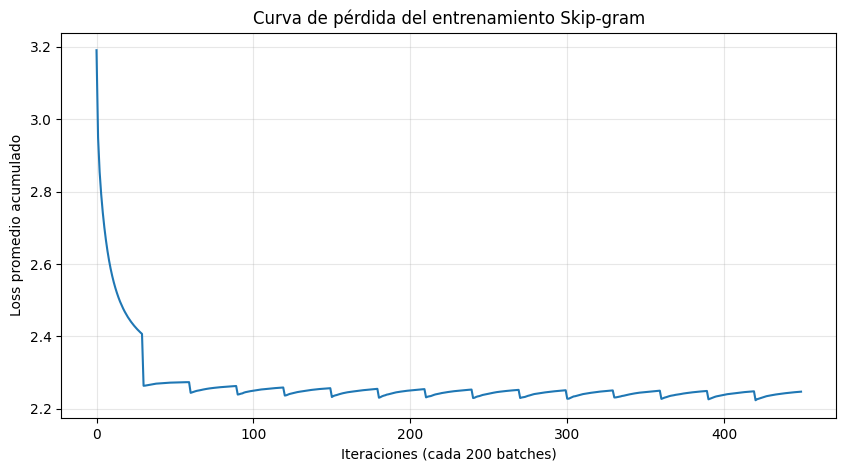

Gráfico guardado en data/loss_curve_word2vec.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel(f"Iteraciones (cada {LOG_INTERVAL} batches)")
plt.ylabel("Loss promedio acumulado")
plt.title("Curva de pérdida del entrenamiento Skip-gram")
plt.grid(True, alpha=0.3)
plt.savefig(DATA_DIR / "loss_curve_word2vec.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Gráfico guardado en {DATA_DIR / 'loss_curve_word2vec.png'}")


---

## Notas sobre la implementación

1. **Por qué dos matrices**: el paper original usa dos matrices distintas para "centro" y "contexto". Los embeddings reportados son típicamente los de entrada (`in_embed`).
2. **Inicialización**: la matriz de salida se inicializa en ceros (sugerencia del paper) y la de entrada con valores pequeños uniformes.
3. **Loss**: usamos `F.logsigmoid` por estabilidad numérica en vez de `log(sigmoid(...))`.
4. **Bordes del corpus**: cuando un offset cae fuera del corpus, escogemos un contexto válido alternativo en lugar de descartar el ejemplo, manteniendo `__len__` constante.

